# A5 CW Solutions: Fitting QNMs
### Joey Wee

- Let's start by examining and plotting the data.dat file.

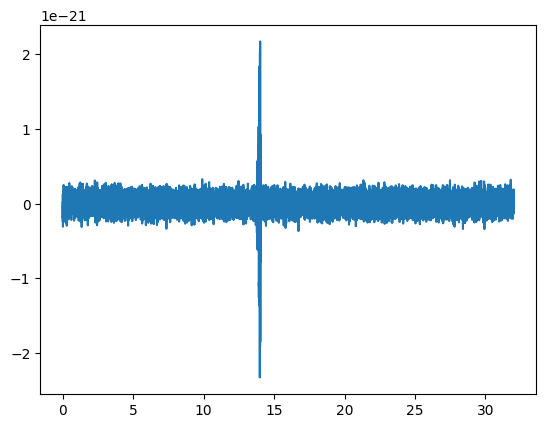

In [5]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data.dat', skiprows=1)

data.shape
plt.plot(data[:,0], data[:,1])

In [7]:
import qnm
qnm.download_data()

Trying to fetch https://duetosymmetry.com/files/qnm/data-0.4.0.tar.bz2


data-0.4.0.tar.bz2: 94.6MB [00:42, 2.23MB/s]                              


Trying to decompress file C:\Users\Joey\.qnm\data-0.4.0.tar.bz2
Data directory C:\Users\Joey\.qnm\data contains 860 pickle files


## Q1: Calculate the dimensionless frequencies
- Consider (l, m, n) = (2, 2, 0) and (3, 3, 0)
- Calculate the dimensionless frequencies.
- Plot the real and imaginary parts of those frequencies.

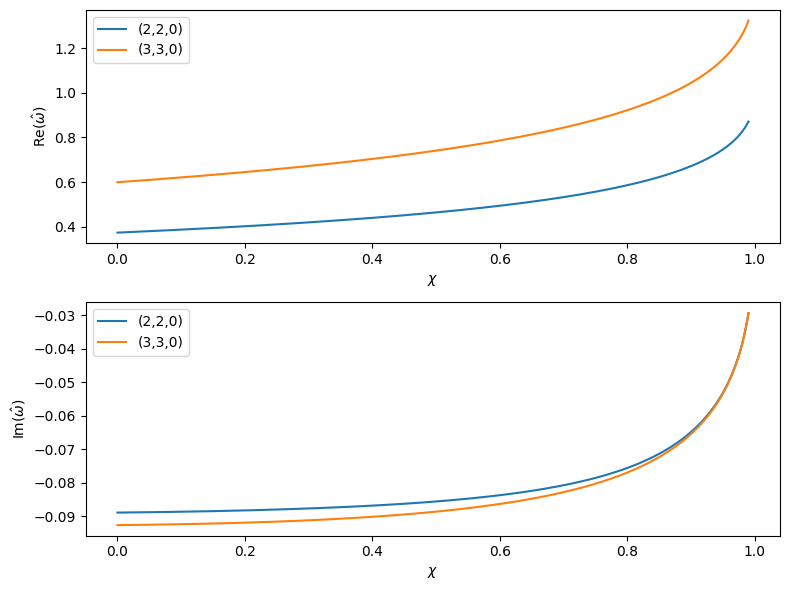

In [13]:
import numpy as np
import qnm
import matplotlib.pyplot as plt

chi_values = np.linspace(0, 0.99, 1000)

# Storage
omega_220 = []
omega_330 = []

# Get mode objects
mode_220 = qnm.modes_cache(s=-2, l=2, m=2, n=0)
mode_330 = qnm.modes_cache(s=-2, l=3, m=3, n=0)

# Loop over chi values
for chi in chi_values:
    w220, _, _ = mode_220(chi)
    w330, _, _ = mode_330(chi)
    omega_220.append(w220)
    omega_330.append(w330)

# Convert to numpy arrays
omega_220 = np.array(omega_220)
omega_330 = np.array(omega_330)

# Now plot real and imaginary parts separately
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.plot(chi_values, omega_220.real, label='(2,2,0)')
ax1.plot(chi_values, omega_330.real, label='(3,3,0)')
ax1.set_ylabel(r'$\mathrm{Re}(\hat{\omega})$')

ax2.plot(chi_values, omega_220.imag, label='(2,2,0)')
ax2.plot(chi_values, omega_330.imag, label='(3,3,0)')
ax2.set_ylabel(r'$\mathrm{Im}(\hat{\omega})$')

for ax in (ax1, ax2):
    ax.set_xlabel(r'$\chi$')
    ax.legend()

plt.tight_layout()
plt.show()